In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [2]:
parquet_path = Path("../data/electrons/electrons_dbscan.parquet")

df = pd.read_parquet(parquet_path)

print(f"Loaded: {parquet_path}")
print(f"Rows: {len(df)}")
print("\nColumns:")
for col in df.columns:
    print(" -", col)

Loaded: ../data/electrons/electrons_dbscan.parquet
Rows: 2695

Columns:
 - event_id
 - particle_id
 - truth_energy
 - truth_px
 - truth_py
 - truth_pz
 - truth_p
 - truth_pt
 - truth_log_pt
 - truth_eta
 - truth_phi
 - truth_charge
 - n_cells
 - cell_x
 - cell_y
 - cell_z
 - cell_eta
 - cell_phi
 - cell_e_total
 - cell_e_calibrated
 - cell_detector
 - cell_t_from_e
 - cell_e_from_e
 - cell_e_from_e_cal
 - cell_dR_truth
 - split


In [3]:
def wrap_phi(phi):
    """
    Wrap angle(s) to [-pi, pi].
    """
    return (phi + np.pi) % (2 * np.pi) - np.pi


def as_array(x):
    """
    Convert a parquet cell-array entry into a numpy array.
    """
    if isinstance(x, np.ndarray):
        return x.astype(float)

    if isinstance(x, list):
        return np.asarray(x, dtype=float)

    try:
        return np.asarray(list(x), dtype=float)
    except TypeError:
        return np.asarray([x], dtype=float)


def pick_column(df, candidates, required=True):
    """
    Pick the first column that exists from a list of possible names.
    """
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise KeyError(
            f"Could not find any of these columns: {candidates}\n\n"
            f"Available columns are:\n{list(df.columns)}"
        )

    return None


def energy_weighted_centroid_phi(cell_phi, cell_energy):
    """
    Compute the energy-weighted average phi of a cluster.

    We do NOT average phi directly, because phi wraps around at -pi/pi.

    Instead, we average the direction vector:

        weighted_cos = sum(E_i cos(phi_i)) / sum(E_i)
        weighted_sin = sum(E_i sin(phi_i)) / sum(E_i)

        centroid_phi = atan2(weighted_sin, weighted_cos)
    """
    cell_phi = np.asarray(cell_phi, dtype=float)
    cell_energy = np.asarray(cell_energy, dtype=float)

    valid = np.isfinite(cell_phi) & np.isfinite(cell_energy)

    cell_phi = cell_phi[valid]
    cell_energy = cell_energy[valid]

    if len(cell_phi) == 0:
        return np.nan

    weights = np.clip(cell_energy, 0.0, None)

    if np.sum(weights) <= 0:
        weights = np.ones_like(cell_phi)

    weighted_cos = np.sum(weights * np.cos(cell_phi)) / np.sum(weights)
    weighted_sin = np.sum(weights * np.sin(cell_phi)) / np.sum(weights)

    return np.arctan2(weighted_sin, weighted_cos)

In [4]:
phi_col = pick_column(
    df,
    [
        "cell_phi",
        "cells_phi",
        "hit_phi",
        "hits_phi",
        "phi_cells",
    ],
)

energy_col = pick_column(
    df,
    [
        "cell_e_calibrated",
        "cells_e_calibrated",
        "cell_energy",
        "cells_energy",
        "cell_e",
        "cells_e",
        "cell_e_total",
        "cells_e_total",
        "total_energy",
    ],
)

truth_phi_col = pick_column(
    df,
    [
        "truth_phi",
        "particle_phi",
        "electron_phi",
    ],
)

print("Using columns:")
print(f"  cell phi:    {phi_col}")
print(f"  cell energy: {energy_col}")
print(f"  truth phi:   {truth_phi_col}")

Using columns:
  cell phi:    cell_phi
  cell energy: cell_e_calibrated
  truth phi:   truth_phi


In [5]:
rows = []

for i, row in df.iterrows():
    cell_phi = as_array(row[phi_col])
    cell_energy = as_array(row[energy_col])

    if len(cell_phi) != len(cell_energy):
        continue

    centroid_phi = energy_weighted_centroid_phi(cell_phi, cell_energy)
    truth_phi = float(row[truth_phi_col])

    if not np.isfinite(centroid_phi) or not np.isfinite(truth_phi):
        continue

    residual = wrap_phi(centroid_phi - truth_phi)

    rows.append(
        {
            "row_index": i,
            "truth_phi": truth_phi,
            "centroid_phi": centroid_phi,
            "centroid_minus_truth_phi": residual,
            "abs_residual": abs(residual),
            "n_cells": len(cell_phi),
        }
    )

summary = pd.DataFrame(rows)

summary.head()

,row_index,truth_phi,centroid_phi,centroid_minus_truth_phi,abs_residual,n_cells
0,0,-1.167060,-1.147088,0.019972,0.019972,821
1,1,1.498956,1.490374,-0.008582,0.008582,1762
2,2,-0.486698,-0.478669,0.008029,0.008029,2838
3,3,2.724917,2.719255,-0.005662,0.005662,3618
4,4,-1.666548,-1.625179,0.041369,0.041369,965


In [6]:
print(f"Valid electrons: {len(summary)}")

print()
print("Residual = centroid_phi - truth_phi, wrapped to [-pi, pi]")
print(f"Mean residual:        {summary['centroid_minus_truth_phi'].mean():.6f} rad")
print(f"Std residual:         {summary['centroid_minus_truth_phi'].std():.6f} rad")
print(f"Median |residual|:    {summary['abs_residual'].median():.6f} rad")
print(f"Mean |residual|:      {summary['abs_residual'].mean():.6f} rad")
print(f"Max |residual|:       {summary['abs_residual'].max():.6f} rad")

Valid electrons: 2695

Residual = centroid_phi - truth_phi, wrapped to [-pi, pi]
Mean residual:        0.004344 rad
Std residual:         0.289910 rad
Median |residual|:    0.015046 rad
Mean |residual|:      0.070181 rad
Max |residual|:       2.987634 rad


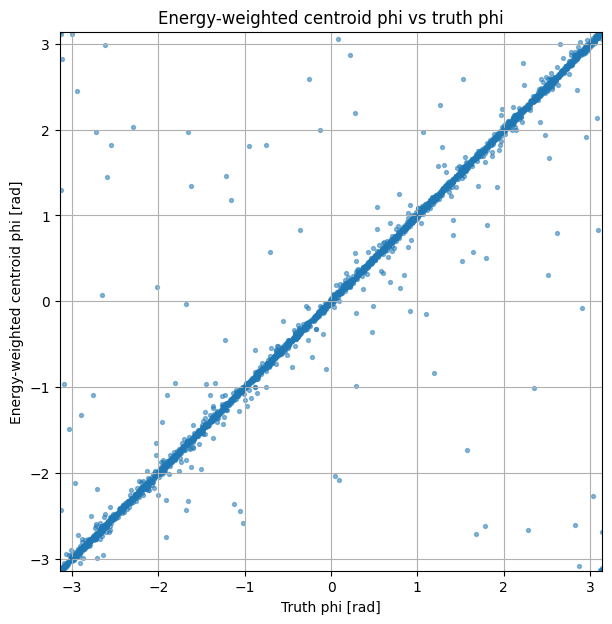

In [7]:
plt.figure(figsize=(7, 7))

plt.scatter(
    summary["truth_phi"],
    summary["centroid_phi"],
    s=8,
    alpha=0.5,
)

plt.plot(
    [-np.pi, np.pi],
    [-np.pi, np.pi],
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Truth phi [rad]")
plt.ylabel("Energy-weighted centroid phi [rad]")
plt.title("Energy-weighted centroid phi vs truth phi")
plt.xlim(-np.pi, np.pi)
plt.ylim(-np.pi, np.pi)
plt.show()

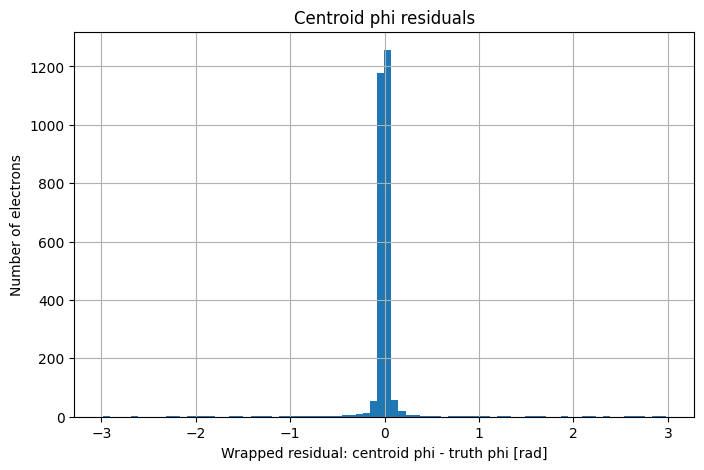

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(
    summary["centroid_minus_truth_phi"],
    bins=80,
)

plt.xlabel("Wrapped residual: centroid phi - truth phi [rad]")
plt.ylabel("Number of electrons")
plt.title("Centroid phi residuals")
plt.show()

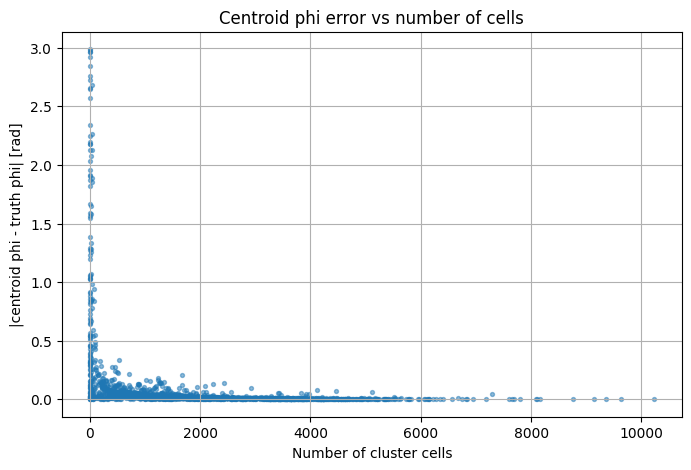

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    summary["n_cells"],
    summary["abs_residual"],
    s=8,
    alpha=0.5,
)

plt.xlabel("Number of cluster cells")
plt.ylabel("|centroid phi - truth phi| [rad]")
plt.title("Centroid phi error vs number of cells")
plt.show()

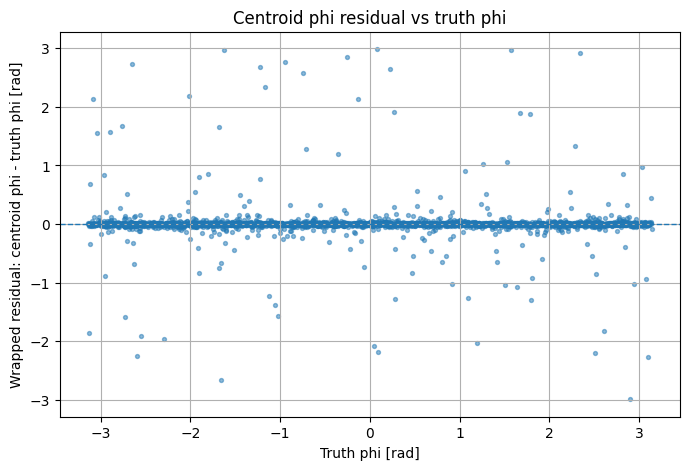

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    summary["truth_phi"],
    summary["centroid_minus_truth_phi"],
    s=8,
    alpha=0.5,
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel("Truth phi [rad]")
plt.ylabel("Wrapped residual: centroid phi - truth phi [rad]")
plt.title("Centroid phi residual vs truth phi")
plt.show()

In [11]:
def get_truth_pt_for_row(row):
    """
    Get truth pT for one electron row.

    Priority:
    1. Use truth_pt if it exists.
    2. Use exp(truth_log_pt) if it exists.
    3. Compute sqrt(px^2 + py^2) if px/py exist.
    """
    if "truth_pt" in row.index:
        return float(row["truth_pt"])

    if "truth_log_pt" in row.index:
        return float(np.exp(row["truth_log_pt"]))

    if "truth_px" in row.index and "truth_py" in row.index:
        px = float(row["truth_px"])
        py = float(row["truth_py"])
        return float(np.sqrt(px**2 + py**2))

    raise KeyError(
        "Could not find truth pT. Need one of: "
        "'truth_pt', 'truth_log_pt', or 'truth_px' + 'truth_py'."
    )


truth_pts = []

for row_index in summary["row_index"]:
    truth_pts.append(get_truth_pt_for_row(df.loc[row_index]))

summary["truth_pt"] = truth_pts
summary["log_truth_pt"] = np.log(summary["truth_pt"])

summary.head()

,row_index,truth_phi,centroid_phi,centroid_minus_truth_phi,abs_residual,n_cells,truth_pt,log_truth_pt
0,0,-1.167060,-1.147088,0.019972,0.019972,821,30.761744,3.426272
1,1,1.498956,1.490374,-0.008582,0.008582,1762,64.469181,4.166187
2,2,-0.486698,-0.478669,0.008029,0.008029,2838,53.633770,3.982179
3,3,2.724917,2.719255,-0.005662,0.005662,3618,32.697185,3.487289
4,4,-1.666548,-1.625179,0.041369,0.041369,965,8.063517,2.087350


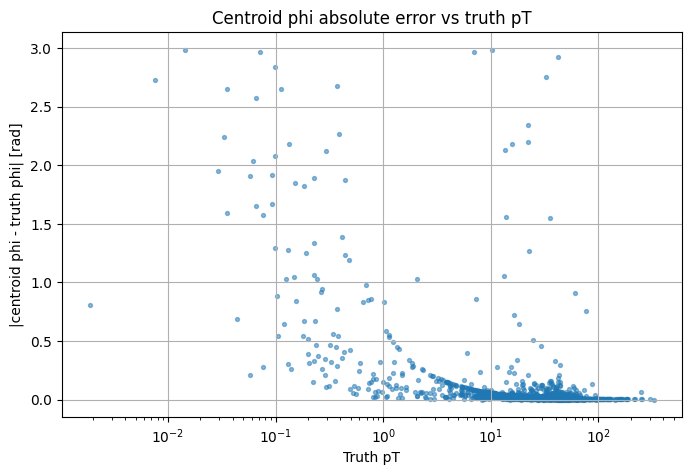

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    summary["truth_pt"],
    summary["abs_residual"],
    s=8,
    alpha=0.5,
)

plt.xscale("log")

plt.xlabel("Truth pT")
plt.ylabel("|centroid phi - truth phi| [rad]")
plt.title("Centroid phi absolute error vs truth pT")
plt.show()

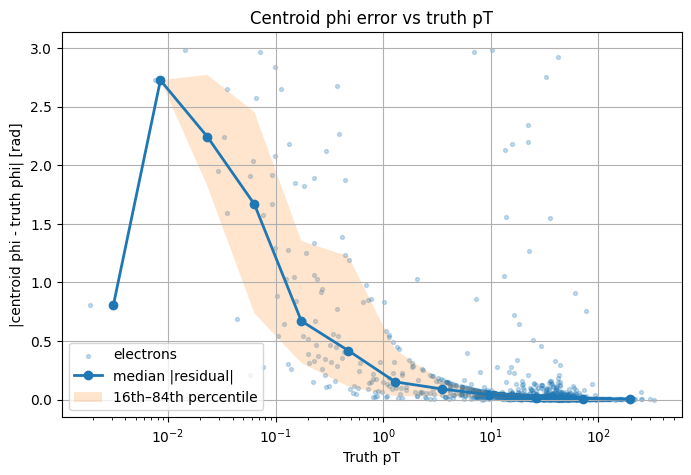

In [13]:
def binned_median(x, y, n_bins=12):
    """
    Compute median y in bins of x.
    Uses log-spaced bins because pT usually spans a wide range.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[valid]
    y = y[valid]

    bins = np.logspace(np.log10(x.min()), np.log10(x.max()), n_bins + 1)

    bin_centers = []
    medians = []
    q16s = []
    q84s = []
    counts = []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (x >= lo) & (x < hi)
        if np.sum(mask) == 0:
            continue

        bin_centers.append(np.sqrt(lo * hi))
        medians.append(np.median(y[mask]))
        q16s.append(np.percentile(y[mask], 16))
        q84s.append(np.percentile(y[mask], 84))
        counts.append(np.sum(mask))

    return (
        np.asarray(bin_centers),
        np.asarray(medians),
        np.asarray(q16s),
        np.asarray(q84s),
        np.asarray(counts),
    )


x = summary["truth_pt"].to_numpy()
y = summary["abs_residual"].to_numpy()

bin_centers, medians, q16s, q84s, counts = binned_median(x, y, n_bins=12)

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    s=8,
    alpha=0.25,
    label="electrons",
)

plt.plot(
    bin_centers,
    medians,
    marker="o",
    linewidth=2,
    label="median |residual|",
)

plt.fill_between(
    bin_centers,
    q16s,
    q84s,
    alpha=0.2,
    label="16th–84th percentile",
)

plt.xscale("log")

plt.xlabel("Truth pT")
plt.ylabel("|centroid phi - truth phi| [rad]")
plt.title("Centroid phi error vs truth pT")
plt.legend()
plt.show()

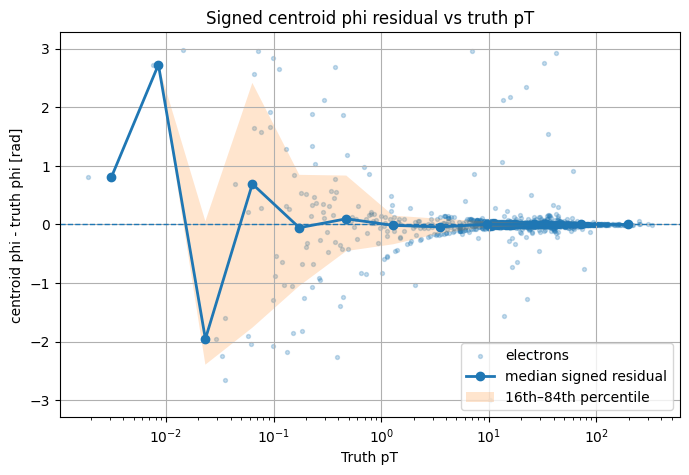

In [14]:
x = summary["truth_pt"].to_numpy()
y = summary["centroid_minus_truth_phi"].to_numpy()

bin_centers, medians, q16s, q84s, counts = binned_median(x, y, n_bins=12)

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    s=8,
    alpha=0.25,
    label="electrons",
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.plot(
    bin_centers,
    medians,
    marker="o",
    linewidth=2,
    label="median signed residual",
)

plt.fill_between(
    bin_centers,
    q16s,
    q84s,
    alpha=0.2,
    label="16th–84th percentile",
)

plt.xscale("log")

plt.xlabel("Truth pT")
plt.ylabel("centroid phi - truth phi [rad]")
plt.title("Signed centroid phi residual vs truth pT")
plt.legend()
plt.show()